# Ingeniería de Características

En este notebook transformo los datos operativos brutos de la red de clínicas veterinarias Mexikans en características analíticas estructuradas adecuadas para análisis avanzados y modelos de machine learning.

La ingeniería de características es un paso crítico en el flujo de trabajo de ciencia de datos porque nos permite capturar patrones de comportamiento, dinámicas operativas y señales temporales de demanda presentes en los datos de visitas.

Las características creadas en este notebook apoyan múltiples tareas analíticas a lo largo del proyecto:

• Análisis del comportamiento de los clientes  
• Segmentación de clínicas veterinarias  
• Pronóstico de demanda  
• Explicabilidad de modelos  

El proceso de ingeniería de características se organiza en cuatro capas analíticas principales:

**Características de Comportamiento a Nivel de Mascota**

Estas características capturan cómo las mascotas individuales interactúan con los servicios veterinarios, incluyendo frecuencia de visitas, patrones de gasto y nivel de interacción a lo largo del tiempo con la red de clínicas.

**Características a Nivel de Cliente**

Dado que los clientes pueden tener múltiples mascotas, agregar la información a nivel de cliente permite estimar el valor de vida del cliente y la intensidad de su interacción con los servicios veterinarios.

**Características Operativas a Nivel de Clínica**

Se construyen indicadores operativos para medir el desempeño de las clínicas, la intensidad de la demanda de servicios y la eficiencia operativa en toda la red.

**Características Temporales de Demanda**

Las características de series temporales, como variables rezagadas y estadísticas móviles, capturan el impulso de la demanda, los ciclos estacionales y las tendencias de corto plazo.

Al estructurar los datos a través de estas capas analíticas, creamos datasets listos para modelado que representan con precisión las dinámicas operativas de la red de clínicas veterinarias Mexikans.

In [1]:
"""
Configuración del Entorno
"""

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from datetime import datetime

# Estilo visual consistente
sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (8,5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

np.random.seed(42)

# Configuración de guardado de gráficos
NOTEBOOK_ID = "03_feature_engineering"

FIGURES_DIR = Path("../figures")

def save_plot(name):
    folder = FIGURES_DIR / NOTEBOOK_ID
    folder.mkdir(parents=True, exist_ok=True)

    plt.savefig(
        folder / f"{name}.png",
        dpi=300,
        bbox_inches="tight"
    )

print("Entorno listo.")

Entorno listo.


In [2]:
"""
Cargar Datasets
"""

DATA_PATH = "../data/"

cities_df = pd.read_csv(DATA_PATH + "cities.csv")
clinics_df = pd.read_csv(DATA_PATH + "clinics.csv")
services_df = pd.read_csv(DATA_PATH + "services.csv")
pets_df = pd.read_csv(DATA_PATH + "pets.csv")
calendar_df = pd.read_csv(DATA_PATH + "calendar.csv")
visits_df = pd.read_csv(DATA_PATH + "visits.csv")
daily_metrics_df = pd.read_csv(DATA_PATH + "daily_metrics.csv")

print("Datasets cargados correctamente.")

Datasets cargados correctamente.


In [3]:
"""
Convertir Columnas de Fecha
"""

calendar_df["visit_date"] = pd.to_datetime(calendar_df["visit_date"])
visits_df["visit_date"] = pd.to_datetime(visits_df["visit_date"])
daily_metrics_df["visit_date"] = pd.to_datetime(daily_metrics_df["visit_date"])

print("Columnas de fecha convertidas.")

Columnas de fecha convertidas.


In [4]:
"""
Visión General del Dataset
"""

print("Ciudades:", cities_df.shape)
print("Clínicas:", clinics_df.shape)
print("Servicios:", services_df.shape)
print("Mascotas:", pets_df.shape)
print("Calendario:", calendar_df.shape)
print("Visitas:", visits_df.shape)
print("Métricas Diarias:", daily_metrics_df.shape)

Ciudades: (14, 4)
Clínicas: (50, 7)
Servicios: (8, 4)
Mascotas: (25000, 7)
Calendario: (1827, 10)
Visitas: (753441, 12)
Métricas Diarias: (90917, 7)


## Preparación y Validación de Datos

Antes de construir las características analíticas, realizo una validación básica de los datasets generados en las etapas anteriores del proyecto.

Este paso asegura que los datasets operativos principales sean estructuralmente consistentes y adecuados para la ingeniería de características.

El proceso de validación se enfoca en:

- identificar valores faltantes
- detectar registros duplicados
- verificar la consistencia entre entidades clave como clínicas y mascotas

Realizar estas verificaciones al inicio del flujo de trabajo ayuda a prevenir problemas posteriores durante el modelado y garantiza que el proceso de ingeniería de características se base en datos confiables.

In [5]:
"""
Validación Básica de Datos
"""

print("Valores faltantes\n")

print(visits_df.isnull().sum())

print("\nFilas duplicadas")
print("Visitas:", visits_df.duplicated().sum())
print("Mascotas:", pets_df.duplicated().sum())
print("Clínicas:", clinics_df.duplicated().sum())

print("\nVerificaciones de consistencia")

print("Clínicas en visitas:", visits_df["clinic_id"].nunique())
print("Total de clínicas:", clinics_df["clinic_id"].nunique())

print("Mascotas en visitas:", visits_df["pet_id"].nunique())
print("Total de mascotas:", pets_df["pet_id"].nunique())

Valores faltantes

visit_id            0
visit_date          0
clinic_id           0
customer_id         0
pet_id              0
pet_type            0
service_type        0
treatment_cost      0
medication_cost     0
total_visit_cost    0
appointment_type    0
emergency_visit     0
dtype: int64

Filas duplicadas
Visitas: 0
Mascotas: 0
Clínicas: 0

Verificaciones de consistencia
Clínicas en visitas: 50
Total de clínicas: 50
Mascotas en visitas: 25000
Total de mascotas: 25000


## Ingeniería de Características Temporales

La demanda veterinaria está fuertemente influenciada por patrones temporales.

Los dueños de mascotas suelen programar las visitas según rutinas semanales, campañas de vacunación estacionales y brotes de enfermedades. Estos patrones generan fluctuaciones de demanda predecibles a lo largo del año.

Para capturar estas dinámicas, derivo varios indicadores temporales a partir de la fecha de la visita. Estas variables permiten que los modelos posteriores aprendan:

- ciclos semanales de demanda
- patrones estacionales
- diferencias entre la demanda de días laborales y fines de semana

Estas características temporales desempeñarán más adelante un papel clave en los modelos de pronóstico de demanda.

In [6]:
"""
Características Temporales
"""

visits_df["day_of_week"] = visits_df["visit_date"].dt.dayofweek
visits_df["month"] = visits_df["visit_date"].dt.month
visits_df["week_of_year"] = visits_df["visit_date"].dt.isocalendar().week.astype(int)
visits_df["quarter"] = visits_df["visit_date"].dt.quarter

visits_df["is_weekend"] = visits_df["day_of_week"].isin([5,6]).astype(int)

visits_df.head()

,visit_id,visit_date,clinic_id,customer_id,pet_id,pet_type,service_type,treatment_cost,medication_cost,total_visit_cost,appointment_type,emergency_visit,day_of_week,month,week_of_year,quarter,is_weekend
0,1,2020-01-01,C001,CU07874,P002417,Perro,Dental Cleaning,173.05,24.61,197.66,Walk-in,0,2,1,1,1,0
1,2,2020-01-01,C001,CU07677,P003844,Perro,Vaccination,33.31,16.76,50.07,Walk-in,0,2,1,1,1,0
2,3,2020-01-01,C001,CU11225,P016758,Perro,General Consultation,43.07,16.77,59.85,Scheduled,0,2,1,1,1,0
3,4,2020-01-01,C001,CU12300,P007962,Perro,Vaccination,31.71,11.60,43.31,Walk-in,0,2,1,1,1,0
4,5,2020-01-01,C001,CU11456,P011675,Exótico,Vaccination,22.42,18.69,41.11,Scheduled,0,2,1,1,1,0


## Características de Comportamiento a Nivel de Mascota

Comprender el comportamiento a nivel de mascota es fundamental para analizar la interacción de los clientes con los servicios veterinarios.

Cada mascota genera una secuencia de visitas a lo largo del tiempo, lo que permite construir indicadores de comportamiento que describen con qué frecuencia utilizan los servicios veterinarios y cuánto ingreso generan.

Al agregar los datos de visitas a nivel de mascota, creo características que capturan:

- frecuencia de visitas
- patrones de gasto
- nivel de interacción a lo largo del tiempo con la red veterinaria

Estas características proporcionan la base para el análisis a nivel de cliente y ayudan a cuantificar el valor generado por cada mascota.

In [7]:
"""
Características de Comportamiento de Mascotas
"""

pet_features = (
    visits_df
    .groupby("pet_id")
    .agg(
        visits_per_pet=("visit_id","count"),
        revenue_per_pet=("total_visit_cost","sum"),
        avg_visit_cost_pet=("total_visit_cost","mean"),
        first_visit_date=("visit_date","min"),
        last_visit_date=("visit_date","max")
    )
    .reset_index()
)

pet_features["pet_lifetime_days"] = (
    pet_features["last_visit_date"] -
    pet_features["first_visit_date"]
).dt.days

pet_features["revenue_per_visit_pet"] = (
    pet_features["revenue_per_pet"] /
    pet_features["visits_per_pet"]
)

pet_features.head()

,pet_id,visits_per_pet,revenue_per_pet,avg_visit_cost_pet,first_visit_date,last_visit_date,pet_lifetime_days,revenue_per_visit_pet
0,P000001,20,1939.30,96.965000,2020-03-01,2024-11-14,1719,96.965000
1,P000002,54,7974.20,147.670370,2020-01-03,2024-12-31,1824,147.670370
2,P000003,34,6205.50,182.514706,2020-03-09,2024-12-26,1753,182.514706
3,P000004,21,2015.70,95.985714,2020-03-19,2024-10-17,1673,95.985714
4,P000005,35,5268.29,150.522571,2020-04-17,2024-12-16,1704,150.522571


In [8]:
"""
Unir Características de Mascotas
"""

pets_df = pets_df.merge(
    pet_features,
    on="pet_id",
    how="left"
)

pets_df.head()

,pet_id,customer_id,pet_type,pet_breed,pet_age,pet_age_group,primary_clinic,visits_per_pet,revenue_per_pet,avg_visit_cost_pet,first_visit_date,last_visit_date,pet_lifetime_days,revenue_per_visit_pet
0,P000001,CU06810,Perro,San Bernardo,6,Adulto,C023,20,1939.30,96.965000,2020-03-01,2024-11-14,1719,96.965000
1,P000002,CU05871,Perro,Maltés,2,Joven,C038,54,7974.20,147.670370,2020-01-03,2024-12-31,1824,147.670370
2,P000003,CU06883,Perro,Akita,2,Joven,C039,34,6205.50,182.514706,2020-03-09,2024-12-26,1753,182.514706
3,P000004,CU17681,Perro,Doberman,6,Adulto,C025,21,2015.70,95.985714,2020-03-19,2024-10-17,1673,95.985714
4,P000005,CU06289,Perro,Akita,8,Adulto,C045,35,5268.29,150.522571,2020-04-17,2024-12-16,1704,150.522571


## Características a Nivel de Cliente

Muchos clientes poseen múltiples mascotas, lo que significa que analizar el comportamiento únicamente a nivel de mascota proporciona una visión incompleta de la interacción del cliente.

Para comprender mejor el valor de los clientes, agrego las métricas a nivel de mascota al nivel de cliente.

Estas características ayudan a cuantificar la relación entre los clientes y la red de clínicas veterinarias capturando:

- el número de mascotas que posee cada cliente
- el número total de visitas veterinarias generadas
- los ingresos totales asociados a cada cliente

Estos indicadores proporcionan una primera aproximación del valor de vida del cliente dentro de la red Mexikans.

In [9]:
"""
Características a Nivel de Cliente
"""

customer_features = (
    pets_df
    .groupby("customer_id")
    .agg(
        number_of_pets=("pet_id","count"),
        total_customer_visits=("visits_per_pet","sum"),
        total_customer_revenue=("revenue_per_pet","sum"),
        first_customer_visit=("first_visit_date","min"),
        last_customer_visit=("last_visit_date","max")
    )
    .reset_index()
)

customer_features["customer_lifetime_days"] = (
    customer_features["last_customer_visit"] -
    customer_features["first_customer_visit"]
).dt.days

customer_features.head()

,customer_id,number_of_pets,total_customer_visits,total_customer_revenue,first_customer_visit,last_customer_visit,customer_lifetime_days
0,CU00001,2,70,12191.67,2020-01-04,2024-10-21,1752
1,CU00003,3,53,8394.93,2020-06-22,2024-10-24,1585
2,CU00004,1,32,5237.57,2020-04-11,2024-10-19,1652
3,CU00005,2,47,4384.60,2020-01-25,2024-10-25,1735
4,CU00006,2,43,4848.91,2020-02-05,2024-11-09,1739


In [10]:
"""
Unir Características de Clientes
"""

pets_df = pets_df.merge(
    customer_features,
    on="customer_id",
    how="left"
)

pets_df.head()

,pet_id,customer_id,pet_type,pet_breed,pet_age,pet_age_group,primary_clinic,visits_per_pet,revenue_per_pet,avg_visit_cost_pet,first_visit_date,last_visit_date,pet_lifetime_days,revenue_per_visit_pet,number_of_pets,total_customer_visits,total_customer_revenue,first_customer_visit,last_customer_visit,customer_lifetime_days
0,P000001,CU06810,Perro,San Bernardo,6,Adulto,C023,20,1939.30,96.965000,2020-03-01,2024-11-14,1719,96.965000,2,42,3715.91,2020-01-16,2024-11-14,1764
1,P000002,CU05871,Perro,Maltés,2,Joven,C038,54,7974.20,147.670370,2020-01-03,2024-12-31,1824,147.670370,4,113,15632.85,2020-01-03,2024-12-31,1824
2,P000003,CU06883,Perro,Akita,2,Joven,C039,34,6205.50,182.514706,2020-03-09,2024-12-26,1753,182.514706,4,131,22864.17,2020-01-08,2024-12-26,1814
3,P000004,CU17681,Perro,Doberman,6,Adulto,C025,21,2015.70,95.985714,2020-03-19,2024-10-17,1673,95.985714,1,21,2015.70,2020-03-19,2024-10-17,1673
4,P000005,CU06289,Perro,Akita,8,Adulto,C045,35,5268.29,150.522571,2020-04-17,2024-12-16,1704,150.522571,5,159,26805.63,2020-01-22,2024-12-19,1793


## Desempeño Operativo de las Clínicas

A nivel operativo, las clínicas veterinarias difieren significativamente en términos de intensidad de demanda, generación de ingresos y utilización de recursos.

Para analizar estas diferencias, construyo indicadores de desempeño a nivel de clínica agregando la actividad a nivel de visitas.

Estas características nos permiten medir:

- la demanda total atendida por cada clínica
- la generación de ingresos en toda la red
- el número de clientes y mascotas únicos atendidos
- la proporción de visitas de emergencia

Estos indicadores se utilizarán más adelante para segmentar las clínicas según sus características operativas.

In [11]:
"""
Características de Desempeño a Nivel de Clínica
"""

clinic_features = (
    visits_df
    .groupby("clinic_id")
    .agg(
        clinic_total_visits=("visit_id", "count"),
        clinic_total_revenue=("total_visit_cost", "sum"),
        clinic_avg_visit_revenue=("total_visit_cost", "mean"),
        clinic_unique_customers=("customer_id", "nunique"),
        clinic_unique_pets=("pet_id", "nunique"),
        emergency_visits=("emergency_visit", "sum")
    )
    .reset_index()
)

clinic_features["emergency_visit_ratio"] = (
    clinic_features["emergency_visits"] /
    clinic_features["clinic_total_visits"]
)

clinic_features.head()

,clinic_id,clinic_total_visits,clinic_total_revenue,clinic_avg_visit_revenue,clinic_unique_customers,clinic_unique_pets,emergency_visits,emergency_visit_ratio
0,C001,11633,1628145.24,139.959189,2467,2654,0,0.000000
1,C002,11712,1651985.20,141.050649,2471,2655,387,0.033043
2,C003,18233,2549763.24,139.843319,3517,3893,0,0.000000
3,C004,16921,2329779.13,137.685665,3273,3621,0,0.000000
4,C005,33497,5113080.30,152.642932,5198,6155,0,0.000000


In [12]:
"""
Unir Características de Clínicas
"""

clinics_df = clinics_df.merge(
    clinic_features,
    on="clinic_id",
    how="left"
)

clinics_df.head()

,clinic_id,city,number_of_veterinarians,clinic_capacity,clinic_popularity,opening_year,emergency_enabled,clinic_total_visits,clinic_total_revenue,clinic_avg_visit_revenue,clinic_unique_customers,clinic_unique_pets,emergency_visits,emergency_visit_ratio
0,C001,Chihuahua,4,36,0.822565,2017,False,11633,1628145.24,139.959189,2467,2654,0,0.000000
1,C002,San Luis Potosí,3,33,0.916858,2023,True,11712,1651985.20,141.050649,2471,2655,387,0.033043
2,C003,Chihuahua,5,40,1.186253,2011,False,18233,2549763.24,139.843319,3517,3893,0,0.000000
3,C004,San Luis Potosí,5,45,0.970062,2015,False,16921,2329779.13,137.685665,3273,3621,0,0.000000
4,C005,Tijuana,6,66,1.098928,2014,False,33497,5113080.30,152.642932,5198,6155,0,0.000000


In [13]:
"""
Métricas Adicionales de Clínicas
"""

clinics_df["clinic_revenue_per_visit"] = (
    clinics_df["clinic_total_revenue"] /
    clinics_df["clinic_total_visits"]
)

clinics_df["visits_per_veterinarian"] = (
    clinics_df["clinic_total_visits"] /
    clinics_df["number_of_veterinarians"]
)

clinics_df["revenue_per_veterinarian"] = (
    clinics_df["clinic_total_revenue"] /
    clinics_df["number_of_veterinarians"]
)

clinics_df["capacity_utilization_ratio"] = (
    clinics_df["clinic_total_visits"] /
    clinics_df["clinic_capacity"]
)

clinics_df.head()

,clinic_id,city,number_of_veterinarians,clinic_capacity,clinic_popularity,opening_year,emergency_enabled,clinic_total_visits,clinic_total_revenue,clinic_avg_visit_revenue,clinic_unique_customers,clinic_unique_pets,emergency_visits,emergency_visit_ratio,clinic_revenue_per_visit,visits_per_veterinarian,revenue_per_veterinarian,capacity_utilization_ratio
0,C001,Chihuahua,4,36,0.822565,2017,False,11633,1628145.24,139.959189,2467,2654,0,0.000000,139.959189,2908.250000,407036.310000,323.138889
1,C002,San Luis Potosí,3,33,0.916858,2023,True,11712,1651985.20,141.050649,2471,2655,387,0.033043,141.050649,3904.000000,550661.733333,354.909091
2,C003,Chihuahua,5,40,1.186253,2011,False,18233,2549763.24,139.843319,3517,3893,0,0.000000,139.843319,3646.600000,509952.648000,455.825000
3,C004,San Luis Potosí,5,45,0.970062,2015,False,16921,2329779.13,137.685665,3273,3621,0,0.000000,137.685665,3384.200000,465955.826000,376.022222
4,C005,Tijuana,6,66,1.098928,2014,False,33497,5113080.30,152.642932,5198,6155,0,0.000000,152.642932,5582.833333,852180.050000,507.530303


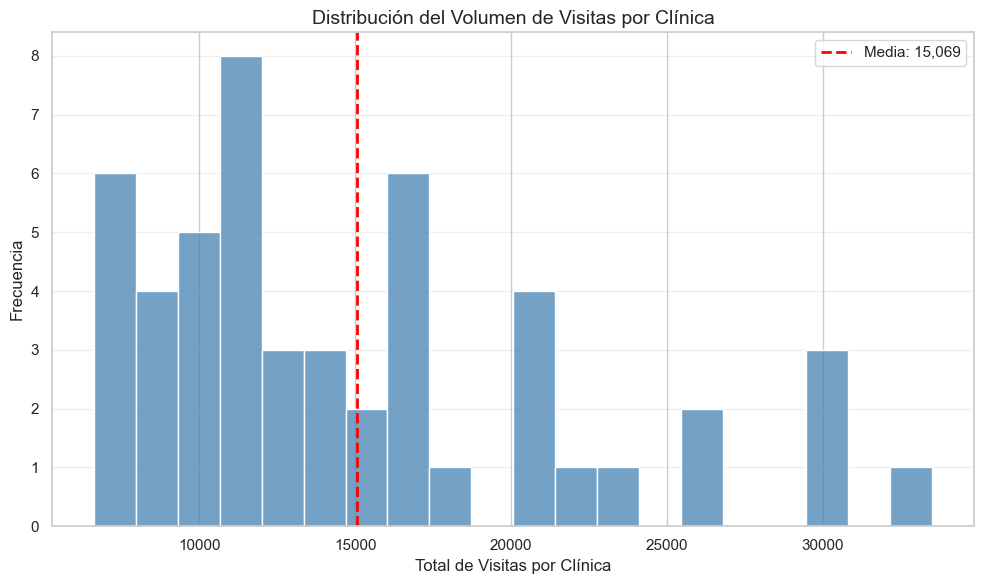

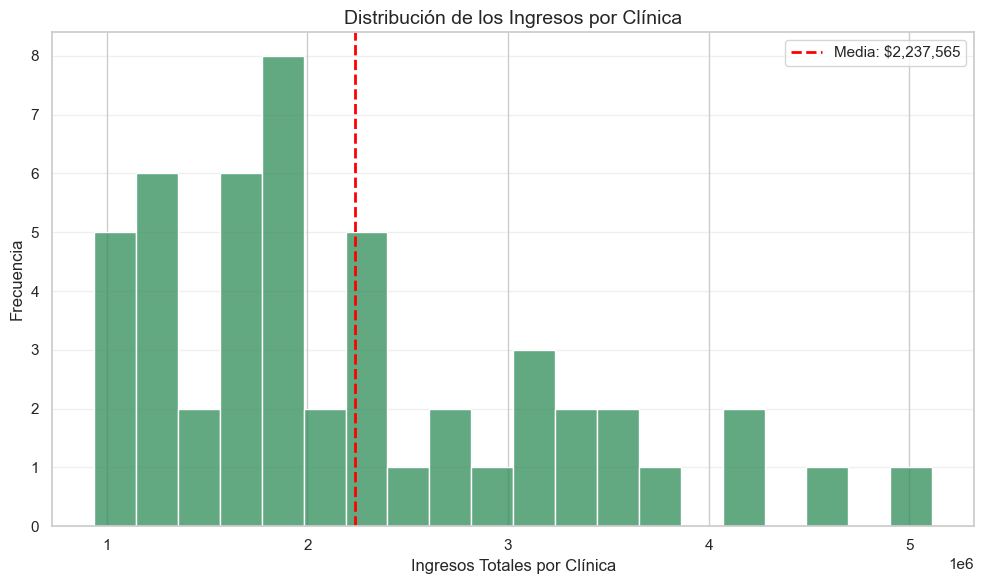

In [14]:
"""
Visualización del Desempeño de las Clínicas
"""

# Distribución de visitas por clínica
plt.figure(figsize=(10,6))

sns.histplot(
    clinics_df["clinic_total_visits"],
    bins=20,
    color="steelblue"
)

mean_visits = clinics_df["clinic_total_visits"].mean()

plt.axvline(
    mean_visits,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Media: {mean_visits:,.0f}"
)

plt.title("Distribución del Volumen de Visitas por Clínica")
plt.xlabel("Total de Visitas por Clínica")
plt.ylabel("Frecuencia")

plt.legend()

plt.grid(axis="y", alpha=0.3)

save_plot("clinic_visits_distribution")

plt.tight_layout()

plt.show()



# Distribución de ingresos por clínica
plt.figure(figsize=(10,6))

sns.histplot(
    clinics_df["clinic_total_revenue"],
    bins=20,
    color="seagreen"
)

mean_revenue = clinics_df["clinic_total_revenue"].mean()

plt.axvline(
    mean_revenue,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Media: ${mean_revenue:,.0f}"
)

plt.title("Distribución de los Ingresos por Clínica")
plt.xlabel("Ingresos Totales por Clínica")
plt.ylabel("Frecuencia")

plt.legend()

plt.grid(axis="y", alpha=0.3)

save_plot("clinic_revenue_distribution")

plt.tight_layout()

plt.show()

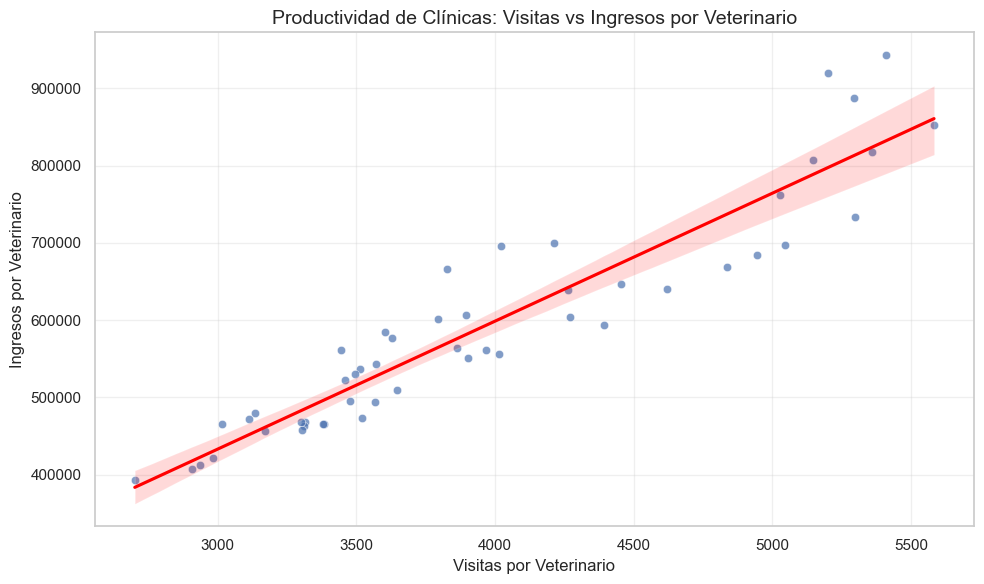

In [15]:
"""
Análisis de Productividad de Clínicas
"""

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=clinics_df,
    x="visits_per_veterinarian",
    y="revenue_per_veterinarian",
    alpha=0.7
)

sns.regplot(
    data=clinics_df,
    x="visits_per_veterinarian",
    y="revenue_per_veterinarian",
    scatter=False,
    color="red"
)

plt.title("Productividad de Clínicas: Visitas vs Ingresos por Veterinario")
plt.xlabel("Visitas por Veterinario")
plt.ylabel("Ingresos por Veterinario")

plt.grid(alpha=0.3)

save_plot("clinic_productivity_scatter")

plt.tight_layout()

plt.show()

## Serie Temporal de Demanda Diaria

El pronóstico de demanda requiere datos estructurados de series temporales.

Dado que el dataset original registra visitas veterinarias individuales, el primer paso es agregar la actividad de visitas en una serie diaria de demanda para cada clínica.

Esta transformación convierte el dataset basado en eventos en una representación de serie temporal de la actividad de las clínicas, capturando:

- volumen diario de visitas
- ingresos diarios generados
- número de mascotas únicas atendidas
- número de clientes únicos atendidos

Este dataset constituye la base para la ingeniería de características de series temporales y los modelos de pronóstico de demanda.

In [16]:
"""
Dataset de Demanda Diaria
"""

daily_demand_df = (
    visits_df
    .groupby(["clinic_id", "visit_date"])
    .agg(
        daily_visits=("visit_id", "count"),
        daily_revenue=("total_visit_cost", "sum"),
        unique_pets=("pet_id", "nunique"),
        unique_customers=("customer_id", "nunique")
    )
    .reset_index()
)

daily_demand_df = daily_demand_df.sort_values(
    ["clinic_id", "visit_date"]
)

daily_demand_df.head()

,clinic_id,visit_date,daily_visits,daily_revenue,unique_pets,unique_customers
0,C001,2020-01-01,5,392.00,5,5
1,C001,2020-01-02,9,1588.72,9,9
2,C001,2020-01-03,4,949.37,4,4
3,C001,2020-01-04,5,770.03,5,5
4,C001,2020-01-05,8,518.60,8,8


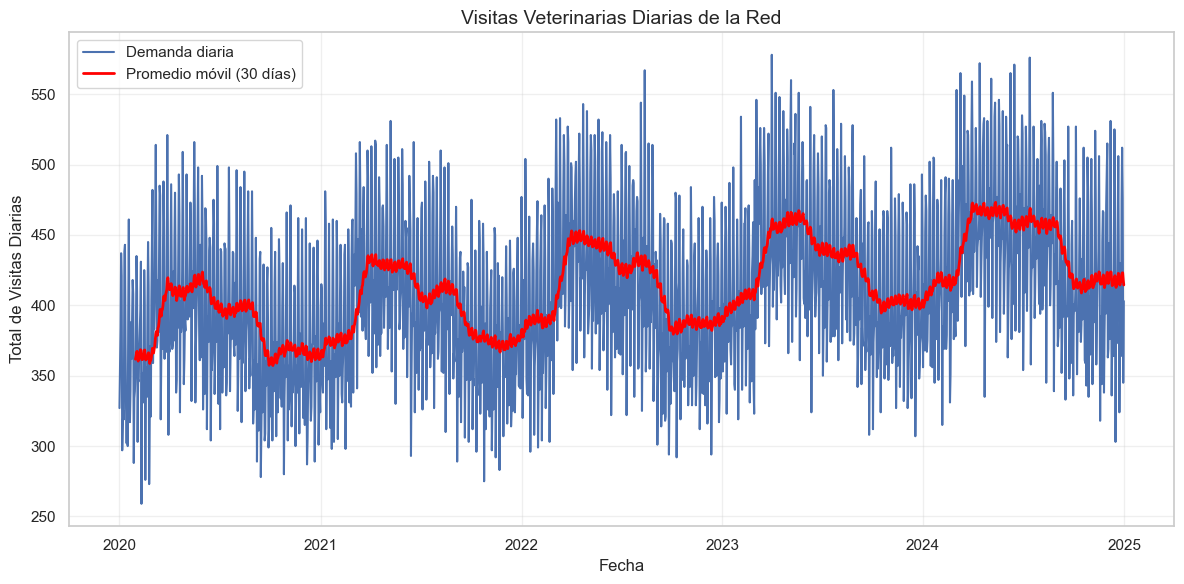

In [17]:
"""
Visualización de la Demanda de la Red
"""

network_demand = (
    daily_demand_df
    .groupby("visit_date")["daily_visits"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(12,6))

sns.lineplot(
    data=network_demand,
    x="visit_date",
    y="daily_visits",
    label="Demanda diaria"
)

rolling_mean = network_demand["daily_visits"].rolling(30).mean()

plt.plot(
    network_demand["visit_date"],
    rolling_mean,
    color="red",
    linewidth=2,
    label="Promedio móvil (30 días)"
)

plt.title("Visitas Veterinarias Diarias de la Red")
plt.xlabel("Fecha")
plt.ylabel("Total de Visitas Diarias")

plt.legend()

plt.grid(alpha=0.3)

save_plot("network_daily_demand_timeseries")

plt.tight_layout()

plt.show()

In [18]:
"""
Métricas Diarias de Ingresos
"""

daily_demand_df["revenue_per_visit"] = (
    daily_demand_df["daily_revenue"] /
    daily_demand_df["daily_visits"]
)

daily_demand_df.head()

,clinic_id,visit_date,daily_visits,daily_revenue,unique_pets,unique_customers,revenue_per_visit
0,C001,2020-01-01,5,392.00,5,5,78.400000
1,C001,2020-01-02,9,1588.72,9,9,176.524444
2,C001,2020-01-03,4,949.37,4,4,237.342500
3,C001,2020-01-04,5,770.03,5,5,154.006000
4,C001,2020-01-05,8,518.60,8,8,64.825000


## Ingeniería de Características para Pronóstico

Predecir la demanda veterinaria requiere capturar dependencias temporales dentro de los datos.

Para lograrlo, construyo varias características de series temporales que resumen los patrones históricos de demanda.

Se introducen dos tipos principales de características:

**Características de Rezago (Lag Features)**

Las variables de rezago representan niveles de demanda observados en días anteriores, lo que permite a los modelos de pronóstico aprender la persistencia de la demanda a corto plazo y los patrones semanales.

**Estadísticas Móviles (Rolling Statistics)**

Las métricas móviles resumen el comportamiento reciente de la demanda calculando promedios móviles e indicadores de volatilidad en diferentes ventanas de tiempo.

En conjunto, estas características ayudan a capturar el impulso de la demanda, la estacionalidad y las fluctuaciones entre clínicas.

In [19]:
"""
Características Temporales de Demanda
"""

daily_demand_df["day_of_week"] = (
    daily_demand_df["visit_date"].dt.dayofweek
)

daily_demand_df["month"] = (
    daily_demand_df["visit_date"].dt.month
)

daily_demand_df["week_of_year"] = (
    daily_demand_df["visit_date"]
    .dt.isocalendar()
    .week
    .astype(int)
)

daily_demand_df["quarter"] = (
    daily_demand_df["visit_date"].dt.quarter
)

daily_demand_df["is_weekend"] = (
    daily_demand_df["day_of_week"]
    .isin([5,6])
    .astype(int)
)

daily_demand_df.head()

,clinic_id,visit_date,daily_visits,daily_revenue,unique_pets,unique_customers,revenue_per_visit,day_of_week,month,week_of_year,quarter,is_weekend
0,C001,2020-01-01,5,392.00,5,5,78.400000,2,1,1,1,0
1,C001,2020-01-02,9,1588.72,9,9,176.524444,3,1,1,1,0
2,C001,2020-01-03,4,949.37,4,4,237.342500,4,1,1,1,0
3,C001,2020-01-04,5,770.03,5,5,154.006000,5,1,1,1,1
4,C001,2020-01-05,8,518.60,8,8,64.825000,6,1,1,1,1


In [20]:
"""
Características de Rezago — Demanda de Visitas
"""

daily_demand_df = daily_demand_df.sort_values(
    ["clinic_id", "visit_date"]
)

daily_demand_df["lag_1_visits"] = (
    daily_demand_df
    .groupby("clinic_id")["daily_visits"]
    .shift(1)
)

daily_demand_df["lag_7_visits"] = (
    daily_demand_df
    .groupby("clinic_id")["daily_visits"]
    .shift(7)
)

daily_demand_df["lag_14_visits"] = (
    daily_demand_df
    .groupby("clinic_id")["daily_visits"]
    .shift(14)
)

daily_demand_df["lag_30_visits"] = (
    daily_demand_df
    .groupby("clinic_id")["daily_visits"]
    .shift(30)
)

daily_demand_df.head(15)

,clinic_id,visit_date,daily_visits,daily_revenue,unique_pets,unique_customers,revenue_per_visit,day_of_week,month,week_of_year,quarter,is_weekend,lag_1_visits,lag_7_visits,lag_14_visits,lag_30_visits
0,C001,2020-01-01,5,392.00,5,5,78.400000,2,1,1,1,0,NaN,NaN,NaN,NaN
1,C001,2020-01-02,9,1588.72,9,9,176.524444,3,1,1,1,0,5.0,NaN,NaN,NaN
2,C001,2020-01-03,4,949.37,4,4,237.342500,4,1,1,1,0,9.0,NaN,NaN,NaN
3,C001,2020-01-04,5,770.03,5,5,154.006000,5,1,1,1,1,4.0,NaN,NaN,NaN
4,C001,2020-01-05,8,518.60,8,8,64.825000,6,1,1,1,1,5.0,NaN,NaN,NaN
5,C001,2020-01-06,10,2620.50,10,10,262.050000,0,1,2,1,0,8.0,NaN,NaN,NaN
6,C001,2020-01-07,3,505.97,3,3,168.656667,1,1,2,1,0,10.0,NaN,NaN,NaN
7,C001,2020-01-08,3,125.63,3,3,41.876667,2,1,2,1,0,3.0,5.0,NaN,NaN
8,C001,2020-01-09,5,1212.82,5,5,242.564000,3,1,2,1,0,3.0,9.0,NaN,NaN
9,C001,2020-01-10,9,2082.60,9,9,231.400000,4,1,2,1,0,5.0,4.0,NaN,NaN


In [21]:
"""
Características de Rezago — Ingresos
"""

daily_demand_df["lag_7_revenue"] = (
    daily_demand_df
    .groupby("clinic_id")["daily_revenue"]
    .shift(7)
)

daily_demand_df["lag_30_revenue"] = (
    daily_demand_df
    .groupby("clinic_id")["daily_revenue"]
    .shift(30)
)

daily_demand_df.head(15)

,clinic_id,visit_date,daily_visits,daily_revenue,unique_pets,unique_customers,revenue_per_visit,day_of_week,month,week_of_year,quarter,is_weekend,lag_1_visits,lag_7_visits,lag_14_visits,lag_30_visits,lag_7_revenue,lag_30_revenue
0,C001,2020-01-01,5,392.00,5,5,78.400000,2,1,1,1,0,NaN,NaN,NaN,NaN,NaN,NaN
1,C001,2020-01-02,9,1588.72,9,9,176.524444,3,1,1,1,0,5.0,NaN,NaN,NaN,NaN,NaN
2,C001,2020-01-03,4,949.37,4,4,237.342500,4,1,1,1,0,9.0,NaN,NaN,NaN,NaN,NaN
3,C001,2020-01-04,5,770.03,5,5,154.006000,5,1,1,1,1,4.0,NaN,NaN,NaN,NaN,NaN
4,C001,2020-01-05,8,518.60,8,8,64.825000,6,1,1,1,1,5.0,NaN,NaN,NaN,NaN,NaN
5,C001,2020-01-06,10,2620.50,10,10,262.050000,0,1,2,1,0,8.0,NaN,NaN,NaN,NaN,NaN
6,C001,2020-01-07,3,505.97,3,3,168.656667,1,1,2,1,0,10.0,NaN,NaN,NaN,NaN,NaN
7,C001,2020-01-08,3,125.63,3,3,41.876667,2,1,2,1,0,3.0,5.0,NaN,NaN,392.00,NaN
8,C001,2020-01-09,5,1212.82,5,5,242.564000,3,1,2,1,0,3.0,9.0,NaN,NaN,1588.72,NaN
9,C001,2020-01-10,9,2082.60,9,9,231.400000,4,1,2,1,0,5.0,4.0,NaN,NaN,949.37,NaN


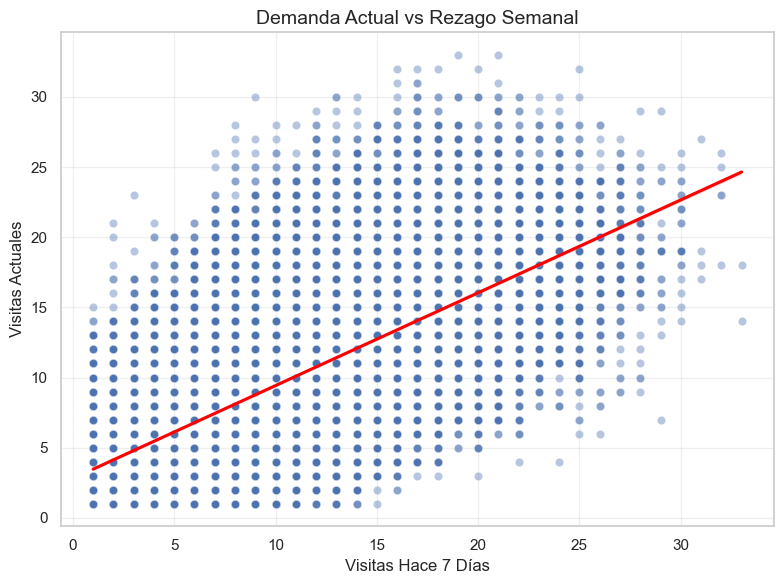

In [22]:
"""
Validación de Características de Rezago
"""

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=daily_demand_df["lag_7_visits"],
    y=daily_demand_df["daily_visits"],
    alpha=0.4
)

sns.regplot(
    x=daily_demand_df["lag_7_visits"],
    y=daily_demand_df["daily_visits"],
    scatter=False,
    color="red"
)

plt.title("Demanda Actual vs Rezago Semanal")
plt.xlabel("Visitas Hace 7 Días")
plt.ylabel("Visitas Actuales")

plt.grid(alpha=0.3)

save_plot("lag7_vs_current_demand")

plt.tight_layout()

plt.show()

In [23]:
"""
Características Móviles — Demanda de Visitas
"""

daily_demand_df["rolling_7d_visits_mean"] = (
    daily_demand_df
    .groupby("clinic_id")["daily_visits"]
    .transform(lambda x: x.rolling(7).mean().shift(1))
)

daily_demand_df["rolling_14d_visits_mean"] = (
    daily_demand_df
    .groupby("clinic_id")["daily_visits"]
    .transform(lambda x: x.rolling(14).mean().shift(1))
)

daily_demand_df["rolling_30d_visits_mean"] = (
    daily_demand_df
    .groupby("clinic_id")["daily_visits"]
    .transform(lambda x: x.rolling(30).mean().shift(1))
)

daily_demand_df.head(20)

,clinic_id,visit_date,daily_visits,daily_revenue,unique_pets,unique_customers,revenue_per_visit,day_of_week,month,week_of_year,quarter,is_weekend,lag_1_visits,lag_7_visits,lag_14_visits,lag_30_visits,lag_7_revenue,lag_30_revenue,rolling_7d_visits_mean,rolling_14d_visits_mean,rolling_30d_visits_mean
0,C001,2020-01-01,5,392.00,5,5,78.400000,2,1,1,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,C001,2020-01-02,9,1588.72,9,9,176.524444,3,1,1,1,0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,C001,2020-01-03,4,949.37,4,4,237.342500,4,1,1,1,0,9.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,C001,2020-01-04,5,770.03,5,5,154.006000,5,1,1,1,1,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,C001,2020-01-05,8,518.60,8,8,64.825000,6,1,1,1,1,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,C001,2020-01-06,10,2620.50,10,10,262.050000,0,1,2,1,0,8.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,C001,2020-01-07,3,505.97,3,3,168.656667,1,1,2,1,0,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,C001,2020-01-08,3,125.63,3,3,41.876667,2,1,2,1,0,3.0,5.0,NaN,NaN,392.00,NaN,6.285714,NaN,NaN
8,C001,2020-01-09,5,1212.82,5,5,242.564000,3,1,2,1,0,3.0,9.0,NaN,NaN,1588.72,NaN,6.000000,NaN,NaN
9,C001,2020-01-10,9,2082.60,9,9,231.400000,4,1,2,1,0,5.0,4.0,NaN,NaN,949.37,NaN,5.428571,NaN,NaN


In [24]:
"""
Características Móviles — Volatilidad de la Demanda
"""

daily_demand_df["rolling_7d_visits_std"] = (
    daily_demand_df
    .groupby("clinic_id")["daily_visits"]
    .transform(lambda x: x.rolling(7).std().shift(1))
)

daily_demand_df["rolling_30d_visits_std"] = (
    daily_demand_df
    .groupby("clinic_id")["daily_visits"]
    .transform(lambda x: x.rolling(30).std().shift(1))
)

daily_demand_df.head(20)

,clinic_id,visit_date,daily_visits,daily_revenue,unique_pets,unique_customers,revenue_per_visit,day_of_week,month,week_of_year,quarter,is_weekend,lag_1_visits,lag_7_visits,lag_14_visits,lag_30_visits,lag_7_revenue,lag_30_revenue,rolling_7d_visits_mean,rolling_14d_visits_mean,rolling_30d_visits_mean,rolling_7d_visits_std,rolling_30d_visits_std
0,C001,2020-01-01,5,392.00,5,5,78.400000,2,1,1,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,C001,2020-01-02,9,1588.72,9,9,176.524444,3,1,1,1,0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,C001,2020-01-03,4,949.37,4,4,237.342500,4,1,1,1,0,9.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,C001,2020-01-04,5,770.03,5,5,154.006000,5,1,1,1,1,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,C001,2020-01-05,8,518.60,8,8,64.825000,6,1,1,1,1,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,C001,2020-01-06,10,2620.50,10,10,262.050000,0,1,2,1,0,8.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,C001,2020-01-07,3,505.97,3,3,168.656667,1,1,2,1,0,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,C001,2020-01-08,3,125.63,3,3,41.876667,2,1,2,1,0,3.0,5.0,NaN,NaN,392.00,NaN,6.285714,NaN,NaN,2.690371,NaN
8,C001,2020-01-09,5,1212.82,5,5,242.564000,3,1,2,1,0,3.0,9.0,NaN,NaN,1588.72,NaN,6.000000,NaN,NaN,2.943920,NaN
9,C001,2020-01-10,9,2082.60,9,9,231.400000,4,1,2,1,0,5.0,4.0,NaN,NaN,949.37,NaN,5.428571,NaN,NaN,2.636737,NaN


In [25]:
"""
Características Móviles — Ingresos
"""

daily_demand_df["rolling_7d_revenue_mean"] = (
    daily_demand_df
    .groupby("clinic_id")["daily_revenue"]
    .transform(lambda x: x.rolling(7).mean().shift(1))
)

daily_demand_df["rolling_30d_revenue_mean"] = (
    daily_demand_df
    .groupby("clinic_id")["daily_revenue"]
    .transform(lambda x: x.rolling(30).mean().shift(1))
)

daily_demand_df.head(20)

,clinic_id,visit_date,daily_visits,daily_revenue,unique_pets,unique_customers,revenue_per_visit,day_of_week,month,week_of_year,quarter,is_weekend,lag_1_visits,lag_7_visits,lag_14_visits,lag_30_visits,lag_7_revenue,lag_30_revenue,rolling_7d_visits_mean,rolling_14d_visits_mean,rolling_30d_visits_mean,rolling_7d_visits_std,rolling_30d_visits_std,rolling_7d_revenue_mean,rolling_30d_revenue_mean
0,C001,2020-01-01,5,392.00,5,5,78.400000,2,1,1,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,C001,2020-01-02,9,1588.72,9,9,176.524444,3,1,1,1,0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,C001,2020-01-03,4,949.37,4,4,237.342500,4,1,1,1,0,9.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,C001,2020-01-04,5,770.03,5,5,154.006000,5,1,1,1,1,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,C001,2020-01-05,8,518.60,8,8,64.825000,6,1,1,1,1,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,C001,2020-01-06,10,2620.50,10,10,262.050000,0,1,2,1,0,8.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,C001,2020-01-07,3,505.97,3,3,168.656667,1,1,2,1,0,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,C001,2020-01-08,3,125.63,3,3,41.876667,2,1,2,1,0,3.0,5.0,NaN,NaN,392.00,NaN,6.285714,NaN,NaN,2.690371,NaN,1049.312857,NaN
8,C001,2020-01-09,5,1212.82,5,5,242.564000,3,1,2,1,0,3.0,9.0,NaN,NaN,1588.72,NaN,6.000000,NaN,NaN,2.943920,NaN,1011.260000,NaN
9,C001,2020-01-10,9,2082.60,9,9,231.400000,4,1,2,1,0,5.0,4.0,NaN,NaN,949.37,NaN,5.428571,NaN,NaN,2.636737,NaN,957.560000,NaN


In [26]:
"""
Indicador de Tendencia de Demanda
"""

daily_demand_df["demand_trend_7d"] = (
    daily_demand_df["rolling_7d_visits_mean"] -
    daily_demand_df["rolling_30d_visits_mean"]
)

daily_demand_df.head(20)

,clinic_id,visit_date,daily_visits,daily_revenue,unique_pets,unique_customers,revenue_per_visit,day_of_week,month,week_of_year,quarter,is_weekend,lag_1_visits,lag_7_visits,lag_14_visits,lag_30_visits,lag_7_revenue,lag_30_revenue,rolling_7d_visits_mean,rolling_14d_visits_mean,rolling_30d_visits_mean,rolling_7d_visits_std,rolling_30d_visits_std,rolling_7d_revenue_mean,rolling_30d_revenue_mean,demand_trend_7d
0,C001,2020-01-01,5,392.00,5,5,78.400000,2,1,1,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,C001,2020-01-02,9,1588.72,9,9,176.524444,3,1,1,1,0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,C001,2020-01-03,4,949.37,4,4,237.342500,4,1,1,1,0,9.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,C001,2020-01-04,5,770.03,5,5,154.006000,5,1,1,1,1,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,C001,2020-01-05,8,518.60,8,8,64.825000,6,1,1,1,1,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,C001,2020-01-06,10,2620.50,10,10,262.050000,0,1,2,1,0,8.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,C001,2020-01-07,3,505.97,3,3,168.656667,1,1,2,1,0,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,C001,2020-01-08,3,125.63,3,3,41.876667,2,1,2,1,0,3.0,5.0,NaN,NaN,392.00,NaN,6.285714,NaN,NaN,2.690371,NaN,1049.312857,NaN,NaN
8,C001,2020-01-09,5,1212.82,5,5,242.564000,3,1,2,1,0,3.0,9.0,NaN,NaN,1588.72,NaN,6.000000,NaN,NaN,2.943920,NaN,1011.260000,NaN,NaN
9,C001,2020-01-10,9,2082.60,9,9,231.400000,4,1,2,1,0,5.0,4.0,NaN,NaN,949.37,NaN,5.428571,NaN,NaN,2.636737,NaN,957.560000,NaN,NaN


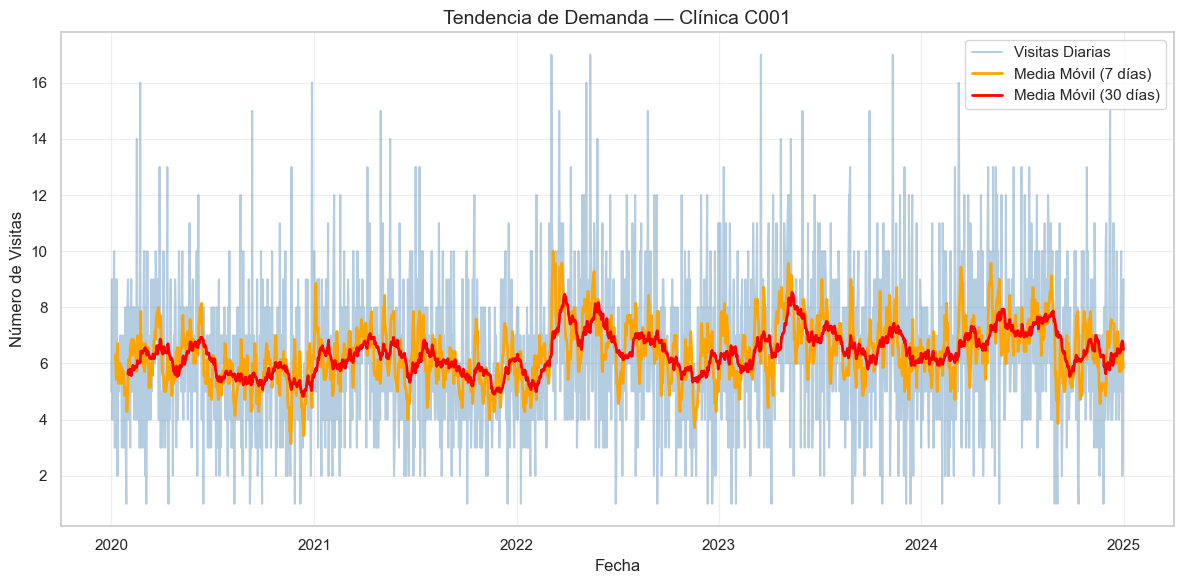

In [27]:
"""
Visualización de Tendencia con Promedios Móviles
"""

sample_clinic = daily_demand_df["clinic_id"].iloc[0]

clinic_series = daily_demand_df[
    daily_demand_df["clinic_id"] == sample_clinic
]

plt.figure(figsize=(12,6))

plt.plot(
    clinic_series["visit_date"],
    clinic_series["daily_visits"],
    label="Visitas Diarias",
    alpha=0.4,
    color="steelblue"
)

plt.plot(
    clinic_series["visit_date"],
    clinic_series["rolling_7d_visits_mean"],
    label="Media Móvil (7 días)",
    linewidth=2,
    color="orange"
)

plt.plot(
    clinic_series["visit_date"],
    clinic_series["rolling_30d_visits_mean"],
    label="Media Móvil (30 días)",
    linewidth=2,
    color="red"
)

plt.title(f"Tendencia de Demanda — Clínica {sample_clinic}")
plt.xlabel("Fecha")
plt.ylabel("Número de Visitas")

plt.legend()

plt.grid(alpha=0.3)

save_plot("clinic_demand_rolling_trends")

plt.tight_layout()

plt.show()

## Datasets para Modelado

Después de construir características de comportamiento, operativas y temporales, el paso final es organizar los datos en datasets listos para modelado.

Diferentes tareas analíticas requieren distintos niveles de agregación, por lo que el proceso de ingeniería de características produce tres datasets principales:

**Dataset de Mascotas / Clientes**

Utilizado para el análisis del comportamiento de los clientes y la estimación del valor de vida del cliente.

**Dataset de Desempeño de Clínicas**

Utilizado para la segmentación de clínicas y el análisis comparativo del desempeño operativo.

**Dataset de Pronóstico de Demanda**

Utilizado para entrenar modelos de machine learning que predicen la demanda veterinaria futura.

Estos datasets se utilizarán en las siguientes etapas del proyecto.

In [28]:
"""
Datasets Finales para Modelado
"""

pet_customer_dataset = pets_df.copy()

clinic_performance_dataset = clinics_df.copy()

demand_forecasting_dataset = daily_demand_df.copy()


print("Dataset de Mascotas / Clientes:", pet_customer_dataset.shape)
print("Dataset de Desempeño de Clínicas:", clinic_performance_dataset.shape)
print("Dataset de Pronóstico de Demanda:", demand_forecasting_dataset.shape)

Dataset de Mascotas / Clientes: (25000, 20)
Dataset de Desempeño de Clínicas: (50, 18)
Dataset de Pronóstico de Demanda: (90917, 26)


In [29]:
"""
Inspección del Dataset de Pronóstico
"""

demand_forecasting_dataset.describe()

,visit_date,daily_visits,daily_revenue,unique_pets,unique_customers,revenue_per_visit,day_of_week,month,week_of_year,quarter,is_weekend,lag_1_visits,lag_7_visits,lag_14_visits,lag_30_visits,lag_7_revenue,lag_30_revenue,rolling_7d_visits_mean,rolling_14d_visits_mean,rolling_30d_visits_mean,rolling_7d_visits_std,rolling_30d_visits_std,rolling_7d_revenue_mean,rolling_30d_revenue_mean,demand_trend_7d
count,90917,90917.000000,90917.000000,90917.000000,90917.000000,90917.000000,90917.000000,90917.000000,90917.000000,90917.000000,90917.000000,90867.000000,90567.000000,90217.00000,89417.000000,90567.000000,89417.000000,90567.000000,90217.000000,89417.000000,90567.000000,89417.000000,90567.000000,89417.000000,89417.000000
mean,2022-07-02 14:57:20.227900160,8.287130,1230.553563,8.230375,8.228186,149.020923,3.003839,6.520596,26.598128,2.507716,0.286338,8.287255,8.285899,8.28631,8.286758,1230.563544,1230.799557,8.288129,8.290020,8.294520,2.775171,2.848765,1230.875568,1231.873027,0.006380
min,2020-01-01 00:00:00,1.000000,21.950000,1.000000,1.000000,21.950000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.00000,1.000000,21.950000,21.950000,1.428571,2.071429,2.800000,0.377964,1.093345,105.700000,274.053000,-4.700000
25%,2021-04-02 00:00:00,5.000000,532.570000,5.000000,5.000000,89.175385,1.000000,4.000000,14.000000,2.000000,0.000000,5.000000,5.000000,5.00000,5.000000,532.340000,532.330000,5.428571,5.428571,5.466667,1.976047,2.233496,768.264286,798.311667,-0.585714
50%,2022-07-03 00:00:00,7.000000,1025.740000,7.000000,7.000000,129.345000,3.000000,7.000000,27.000000,3.000000,0.000000,7.000000,7.000000,7.00000,7.000000,1025.680000,1025.730000,7.285714,7.214286,7.166667,2.609506,2.690127,1092.060000,1078.248333,0.000000
75%,2023-10-03 00:00:00,11.000000,1706.030000,11.000000,11.000000,186.827500,5.000000,10.000000,40.000000,4.000000,1.000000,11.000000,11.000000,11.00000,11.000000,1706.440000,1707.100000,10.285714,10.214286,10.166667,3.387653,3.322684,1583.782857,1583.299000,0.595238
max,2024-12-31 00:00:00,33.000000,7544.650000,33.000000,33.000000,1773.550000,6.000000,12.000000,53.000000,4.000000,1.000000,33.000000,33.000000,33.00000,33.000000,7544.650000,7544.650000,25.000000,22.857143,21.566667,8.783101,6.459867,4126.277143,3483.054667,4.742857
std,NaN,4.794987,910.221412,4.732322,4.730192,86.058673,1.999493,3.447830,15.062550,1.116926,0.452052,4.795109,4.794317,4.79395,4.794544,910.368308,910.517532,3.918491,3.847050,3.809243,1.100880,0.824958,613.683044,567.505777,0.939910


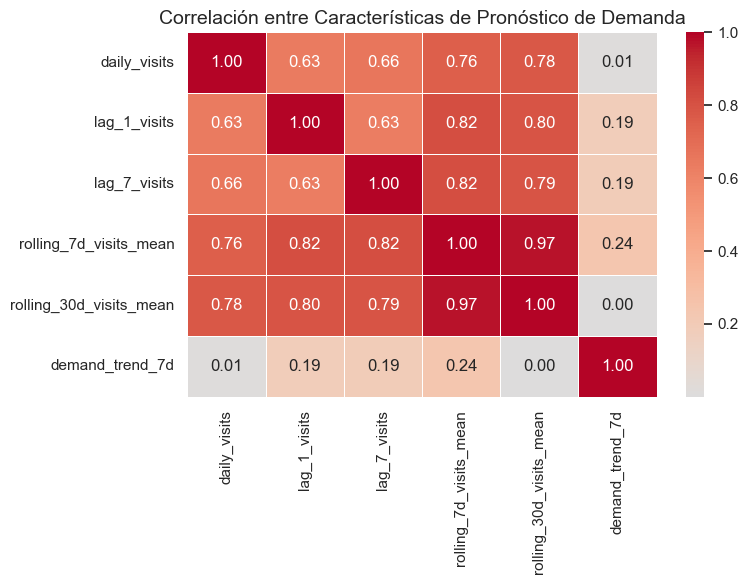

In [30]:
"""
Correlación de Características de Pronóstico
"""

corr_features = demand_forecasting_dataset[
    [
        "daily_visits",
        "lag_1_visits",
        "lag_7_visits",
        "rolling_7d_visits_mean",
        "rolling_30d_visits_mean",
        "demand_trend_7d"
    ]
]

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_features.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlación entre Características de Pronóstico de Demanda")

save_plot("forecast_features_correlation")

plt.tight_layout()

plt.show()

## Documentación de Características

Para mejorar la transparencia y la mantenibilidad del pipeline analítico, resumo las principales características generadas en este notebook.

Documentar las características ayuda a garantizar claridad respecto a:

- el propósito de cada variable
- el dataset en el que se almacena
- su papel analítico dentro del proyecto

In [31]:
feature_summary = pd.DataFrame({

    "feature_name":[
        "visits_per_pet",
        "revenue_per_pet",
        "revenue_per_visit_pet",
        "number_of_pets",
        "total_customer_visits",
        "total_customer_revenue",
        "clinic_total_visits",
        "clinic_total_revenue",
        "clinic_revenue_per_visit",
        "visits_per_veterinarian",
        "capacity_utilization_ratio",
        "lag_7_visits",
        "lag_30_visits",
        "rolling_7d_visits_mean",
        "rolling_30d_visits_mean",
        "demand_trend_7d"
    ],

    "dataset":[
        "pet_customer",
        "pet_customer",
        "pet_customer",
        "pet_customer",
        "pet_customer",
        "pet_customer",
        "clinic_performance",
        "clinic_performance",
        "clinic_performance",
        "clinic_performance",
        "clinic_performance",
        "demand_forecasting",
        "demand_forecasting",
        "demand_forecasting",
        "demand_forecasting",
        "demand_forecasting"
    ],

    "description":[
        "Número total de visitas por mascota",
        "Ingresos totales generados por la mascota",
        "Ingresos promedio por visita para cada mascota",
        "Número de mascotas que posee un cliente",
        "Total de visitas veterinarias generadas por un cliente",
        "Ingresos totales asociados a un cliente",
        "Total de visitas atendidas por cada clínica",
        "Ingresos totales generados por cada clínica",
        "Ingresos promedio por visita en la clínica",
        "Número promedio de visitas atendidas por veterinario",
        "Demanda relativa a la capacidad de la clínica",
        "Visitas observadas una semana antes",
        "Visitas observadas un mes antes",
        "Demanda promedio durante los últimos 7 días",
        "Demanda promedio durante los últimos 30 días",
        "Indicador de tendencia de demanda a corto plazo"
    ]

})

feature_summary

,feature_name,dataset,description
0,visits_per_pet,pet_customer,Número total de visitas por mascota
1,revenue_per_pet,pet_customer,Ingresos totales generados por la mascota
2,revenue_per_visit_pet,pet_customer,Ingresos promedio por visita para cada mascota
3,number_of_pets,pet_customer,Número de mascotas que posee un cliente
4,total_customer_visits,pet_customer,Total de visitas veterinarias generadas por un...
5,total_customer_revenue,pet_customer,Ingresos totales asociados a un cliente
6,clinic_total_visits,clinic_performance,Total de visitas atendidas por cada clínica
7,clinic_total_revenue,clinic_performance,Ingresos totales generados por cada clínica
8,clinic_revenue_per_visit,clinic_performance,Ingresos promedio por visita en la clínica
9,visits_per_veterinarian,clinic_performance,Número promedio de visitas atendidas por veter...


In [32]:
"""
Verificación de Calidad de los Datasets
"""

print("Dataset de Mascotas / Clientes")
print(pet_customer_dataset.isnull().sum())

print("\nDataset de Desempeño de Clínicas")
print(clinic_performance_dataset.isnull().sum())

print("\nDataset de Pronóstico de Demanda")
print(demand_forecasting_dataset.isnull().sum())

Dataset de Mascotas / Clientes
pet_id                    0
customer_id               0
pet_type                  0
pet_breed                 0
pet_age                   0
pet_age_group             0
primary_clinic            0
visits_per_pet            0
revenue_per_pet           0
avg_visit_cost_pet        0
first_visit_date          0
last_visit_date           0
pet_lifetime_days         0
revenue_per_visit_pet     0
number_of_pets            0
total_customer_visits     0
total_customer_revenue    0
first_customer_visit      0
last_customer_visit       0
customer_lifetime_days    0
dtype: int64

Dataset de Desempeño de Clínicas
clinic_id                     0
city                          0
number_of_veterinarians       0
clinic_capacity               0
clinic_popularity             0
opening_year                  0
emergency_enabled             0
clinic_total_visits           0
clinic_total_revenue          0
clinic_avg_visit_revenue      0
clinic_unique_customers       0
clinic_uni

In [33]:
"""
Guardar Datasets de Características
"""

OUTPUT_PATH = "../data/"

pet_customer_dataset.to_csv(
    OUTPUT_PATH + "pet_customer_features.csv",
    index=False
)

clinic_performance_dataset.to_csv(
    OUTPUT_PATH + "clinic_performance_features.csv",
    index=False
)

demand_forecasting_dataset.to_csv(
    OUTPUT_PATH + "demand_forecasting_features.csv",
    index=False
)

print("Datasets de características guardados correctamente.")

Datasets de características guardados correctamente.
